<a href="https://colab.research.google.com/github/aayushkhanna09/ml-lab/blob/main/ml6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.9590643274853801
Confusion Matrix:
 [[ 57   6]
 [  1 107]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94        63
           1       0.95      0.99      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



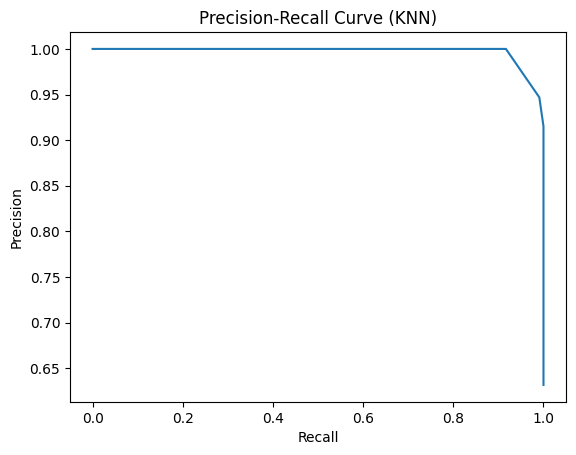

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# Precision-Recall Curve
y_prob_knn = knn.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_knn)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (KNN)")
plt.show()

Accuracy: 0.935672514619883
Confusion Matrix:
 [[ 52  11]
 [  0 108]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.90        63
           1       0.91      1.00      0.95       108

    accuracy                           0.94       171
   macro avg       0.95      0.91      0.93       171
weighted avg       0.94      0.94      0.93       171



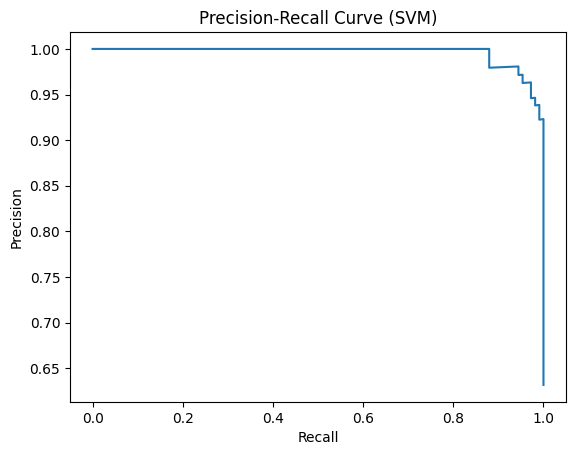

In [2]:
from sklearn.svm import SVC

# Train SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)

# Predict
y_pred_svm = svm.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

# Precision-Recall Curve
y_prob_svm = svm.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_svm)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM)")
plt.show()

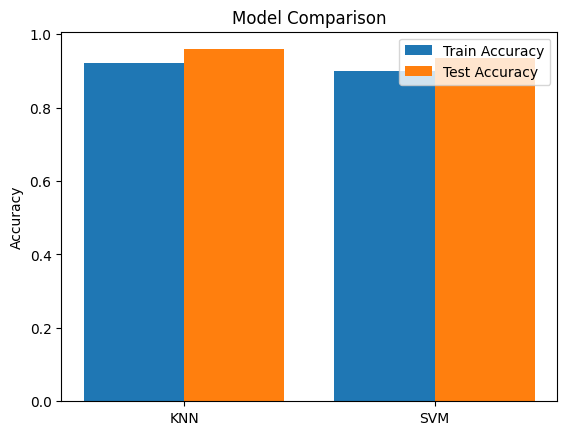

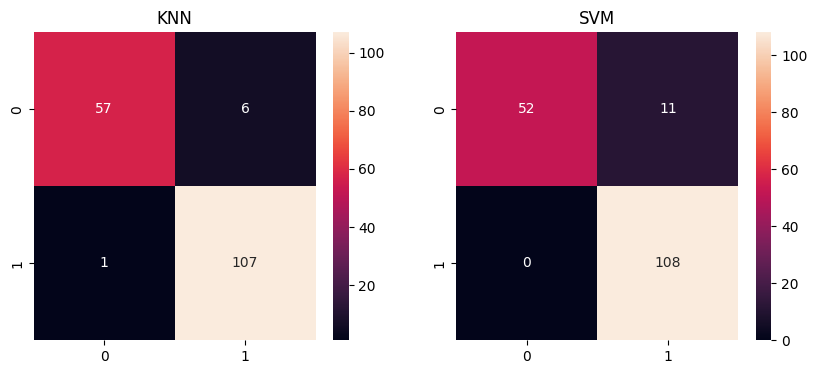

In [3]:
import numpy as np
import seaborn as sns

# Accuracy
train_knn = knn.score(X_train, y_train)
test_knn = knn.score(X_test, y_test)

train_svm = svm.score(X_train, y_train)
test_svm = svm.score(X_test, y_test)

models = ['KNN','SVM']
train_scores = [train_knn, train_svm]
test_scores = [test_knn, test_svm]

# Bar Chart
x = np.arange(len(models))
plt.bar(x-0.2, train_scores, 0.4, label="Train Accuracy")
plt.bar(x+0.2, test_scores, 0.4, label="Test Accuracy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.show()

# Confusion Matrix Heatmap
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_knn, annot=True, fmt="d")
plt.title("KNN")

plt.subplot(1,2,2)
sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("SVM")

plt.show()